# 🩺 Diabetes Prediction using K-Nearest Neighbors (KNN)

**Author:** Akilla Ayuwandewi Putri Edyra 
**Dataset:** [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)  
**Algorithm:** K-Nearest Neighbors (KNN)  
**Tools:** Python, Pandas, Scikit-learn, Seaborn, Matplotlib

---

## 📌 Project Overview

Proyek ini bertujuan untuk **memprediksi apakah seorang pasien menderita diabetes** berdasarkan fitur-fitur medis seperti kadar glukosa, tekanan darah, indeks massa tubuh (BMI), dan lainnya.

Dataset yang digunakan berasal dari **National Institute of Diabetes and Digestive and Kidney Diseases**, terdiri dari 768 data pasien wanita berusia minimal 21 tahun dengan latar belakang suku Pima Indian.

## 🎯 Objectives
- Melakukan eksplorasi dan pembersihan data (EDA & Data Cleaning)
- Membangun model klasifikasi menggunakan algoritma KNN
- Menentukan nilai K optimal untuk performa terbaik
- Mengevaluasi model dengan confusion matrix dan accuracy score


---

## 📋 Table of Contents
1. [Import Libraries](#1-import-libraries)
2. [Load Dataset](#2-load-dataset)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis)
4. [Data Cleaning & Preprocessing](#4-data-cleaning--preprocessing)
5. [Feature Scaling](#5-feature-scaling)
6. [Model Building & K Optimization](#6-model-building--k-optimization)
7. [Model Evaluation](#7-model-evaluation)
8. [Conclusion](#8-conclusion)


---

## 1. Import Libraries

Mengimport semua library yang diperlukan untuk analisis data, visualisasi, dan pemodelan machine learning.

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Pengaturan tampilan
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

print("✅ Libraries berhasil diimport")


✅ Libraries berhasil diimport


---

## 2. Load Dataset

Memuat dataset diabetes dan menampilkan gambaran awal data.

In [14]:
df = pd.read_csv(r'C:\Users\Hype AMD\datasetdiabet\diabetes.csv')

print(f"📊 Shape dataset: {df.shape}")
print(f"📝 Jumlah fitur  : {df.shape[1] - 1}")
print(f"👥 Jumlah sampel : {df.shape[0]}")
df.head(10)


📊 Shape dataset: (768, 9)
📝 Jumlah fitur  : 8
👥 Jumlah sampel : 768


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [16]:
# Informasi tipe data dan missing values
print("📋 Informasi Dataset:")
df.info()


📋 Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [17]:
# Statistik deskriptif
print("📈 Statistik Deskriptif:")
df.describe().T.style.background_gradient(cmap="Blues")


📈 Statistik Deskriptif:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000000,3.845052,3.369578,0.000000,1.000000,3.000000,6.000000,17.000000
Glucose,768.000000,120.894531,31.972618,0.000000,99.000000,117.000000,140.250000,199.000000
BloodPressure,768.000000,69.105469,19.355807,0.000000,62.000000,72.000000,80.000000,122.000000
SkinThickness,768.000000,20.536458,15.952218,0.000000,0.000000,23.000000,32.000000,99.000000
Insulin,768.000000,79.799479,115.244002,0.000000,0.000000,30.500000,127.250000,846.000000
BMI,768.000000,31.992578,7.884160,0.000000,27.300000,32.000000,36.600000,67.100000
DiabetesPedigreeFunction,768.000000,0.471876,0.331329,0.078000,0.243750,0.372500,0.626250,2.420000
Age,768.000000,33.240885,11.760232,21.000000,24.000000,29.000000,41.000000,81.000000
Outcome,768.000000,0.348958,0.476951,0.000000,0.000000,0.000000,1.000000,1.000000


---

## 3. Exploratory Data Analysis

### 3.1 Distribusi Kelas Target

Kolom  adalah variabel target:
- 0 = Tidak Diabetes
- 1 = Diabetes


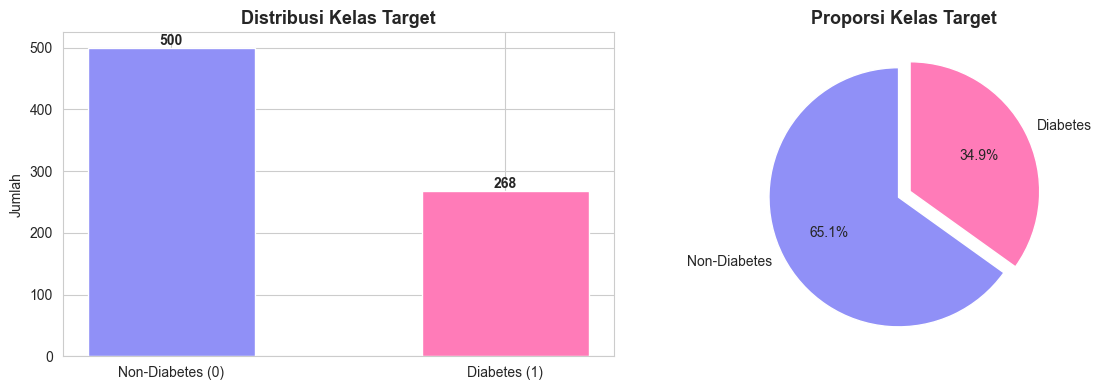

Rasio kelas: 500/268 (Non-Diabetes/Diabetes)


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
outcome_counts = df["Outcome"].value_counts()
axes[0].bar(["Non-Diabetes (0)", "Diabetes (1)"], outcome_counts, color=["#9090F7", "#FF7BB8"], edgecolor="white", width=0.5)
axes[0].set_title("Distribusi Kelas Target", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Jumlah")
for i, v in enumerate(outcome_counts):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# Pie chart
axes[1].pie(outcome_counts, labels=["Non-Diabetes", "Diabetes"], autopct="%1.1f%%",
            colors=["#9090F7", "#FF7BB8"], startangle=90, explode=(0.05, 0.05))
axes[1].set_title("Proporsi Kelas Target", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()
print(f"Rasio kelas: {outcome_counts[0]}/{outcome_counts[1]} (Non-Diabetes/Diabetes)")


### 3.2 Identifikasi Nilai Tidak Valid

Beberapa kolom medis tidak mungkin bernilai 0 secara biologis (misalnya , , ). Nilai 0 pada kolom tersebut kemungkinan merupakan **missing values** yang perlu ditangani.

In [20]:
cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("⚠️  Jumlah nilai 0 yang tidak valid per kolom:")
for col in cols_with_zero:
    zero_count = (df[col] == 0).sum()
    pct = zero_count / len(df) * 100
    print(f"  {col:<25}: {zero_count:>4} ({pct:.1f}%)")


⚠️  Jumlah nilai 0 yang tidak valid per kolom:
  Glucose                  :    5 (0.7%)
  BloodPressure            :   35 (4.6%)
  SkinThickness            :  227 (29.6%)
  Insulin                  :  374 (48.7%)
  BMI                      :   11 (1.4%)


### 3.3 Analisis Korelasi

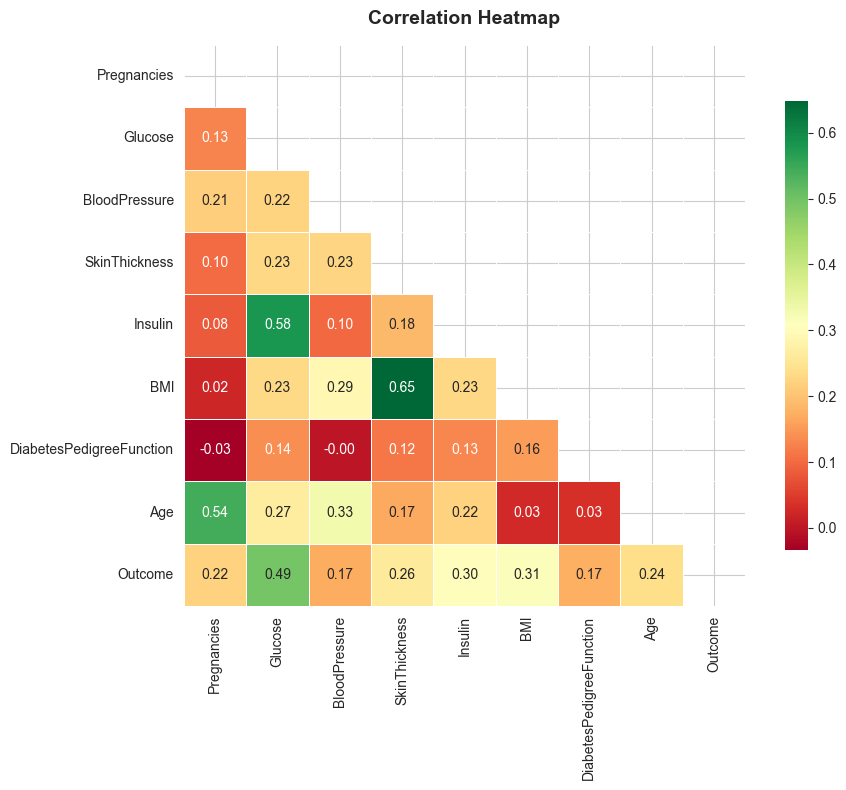

In [21]:
df_temp = df.copy()
df_temp[cols_with_zero] = df_temp[cols_with_zero].replace(0, np.nan)

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(df_temp.corr(), dtype=bool))
sns.heatmap(df_temp.corr(), annot=True, fmt=".2f", cmap="RdYlGn",
            mask=mask, linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()


### 3.4 Pairplot Berdasarkan Outcome

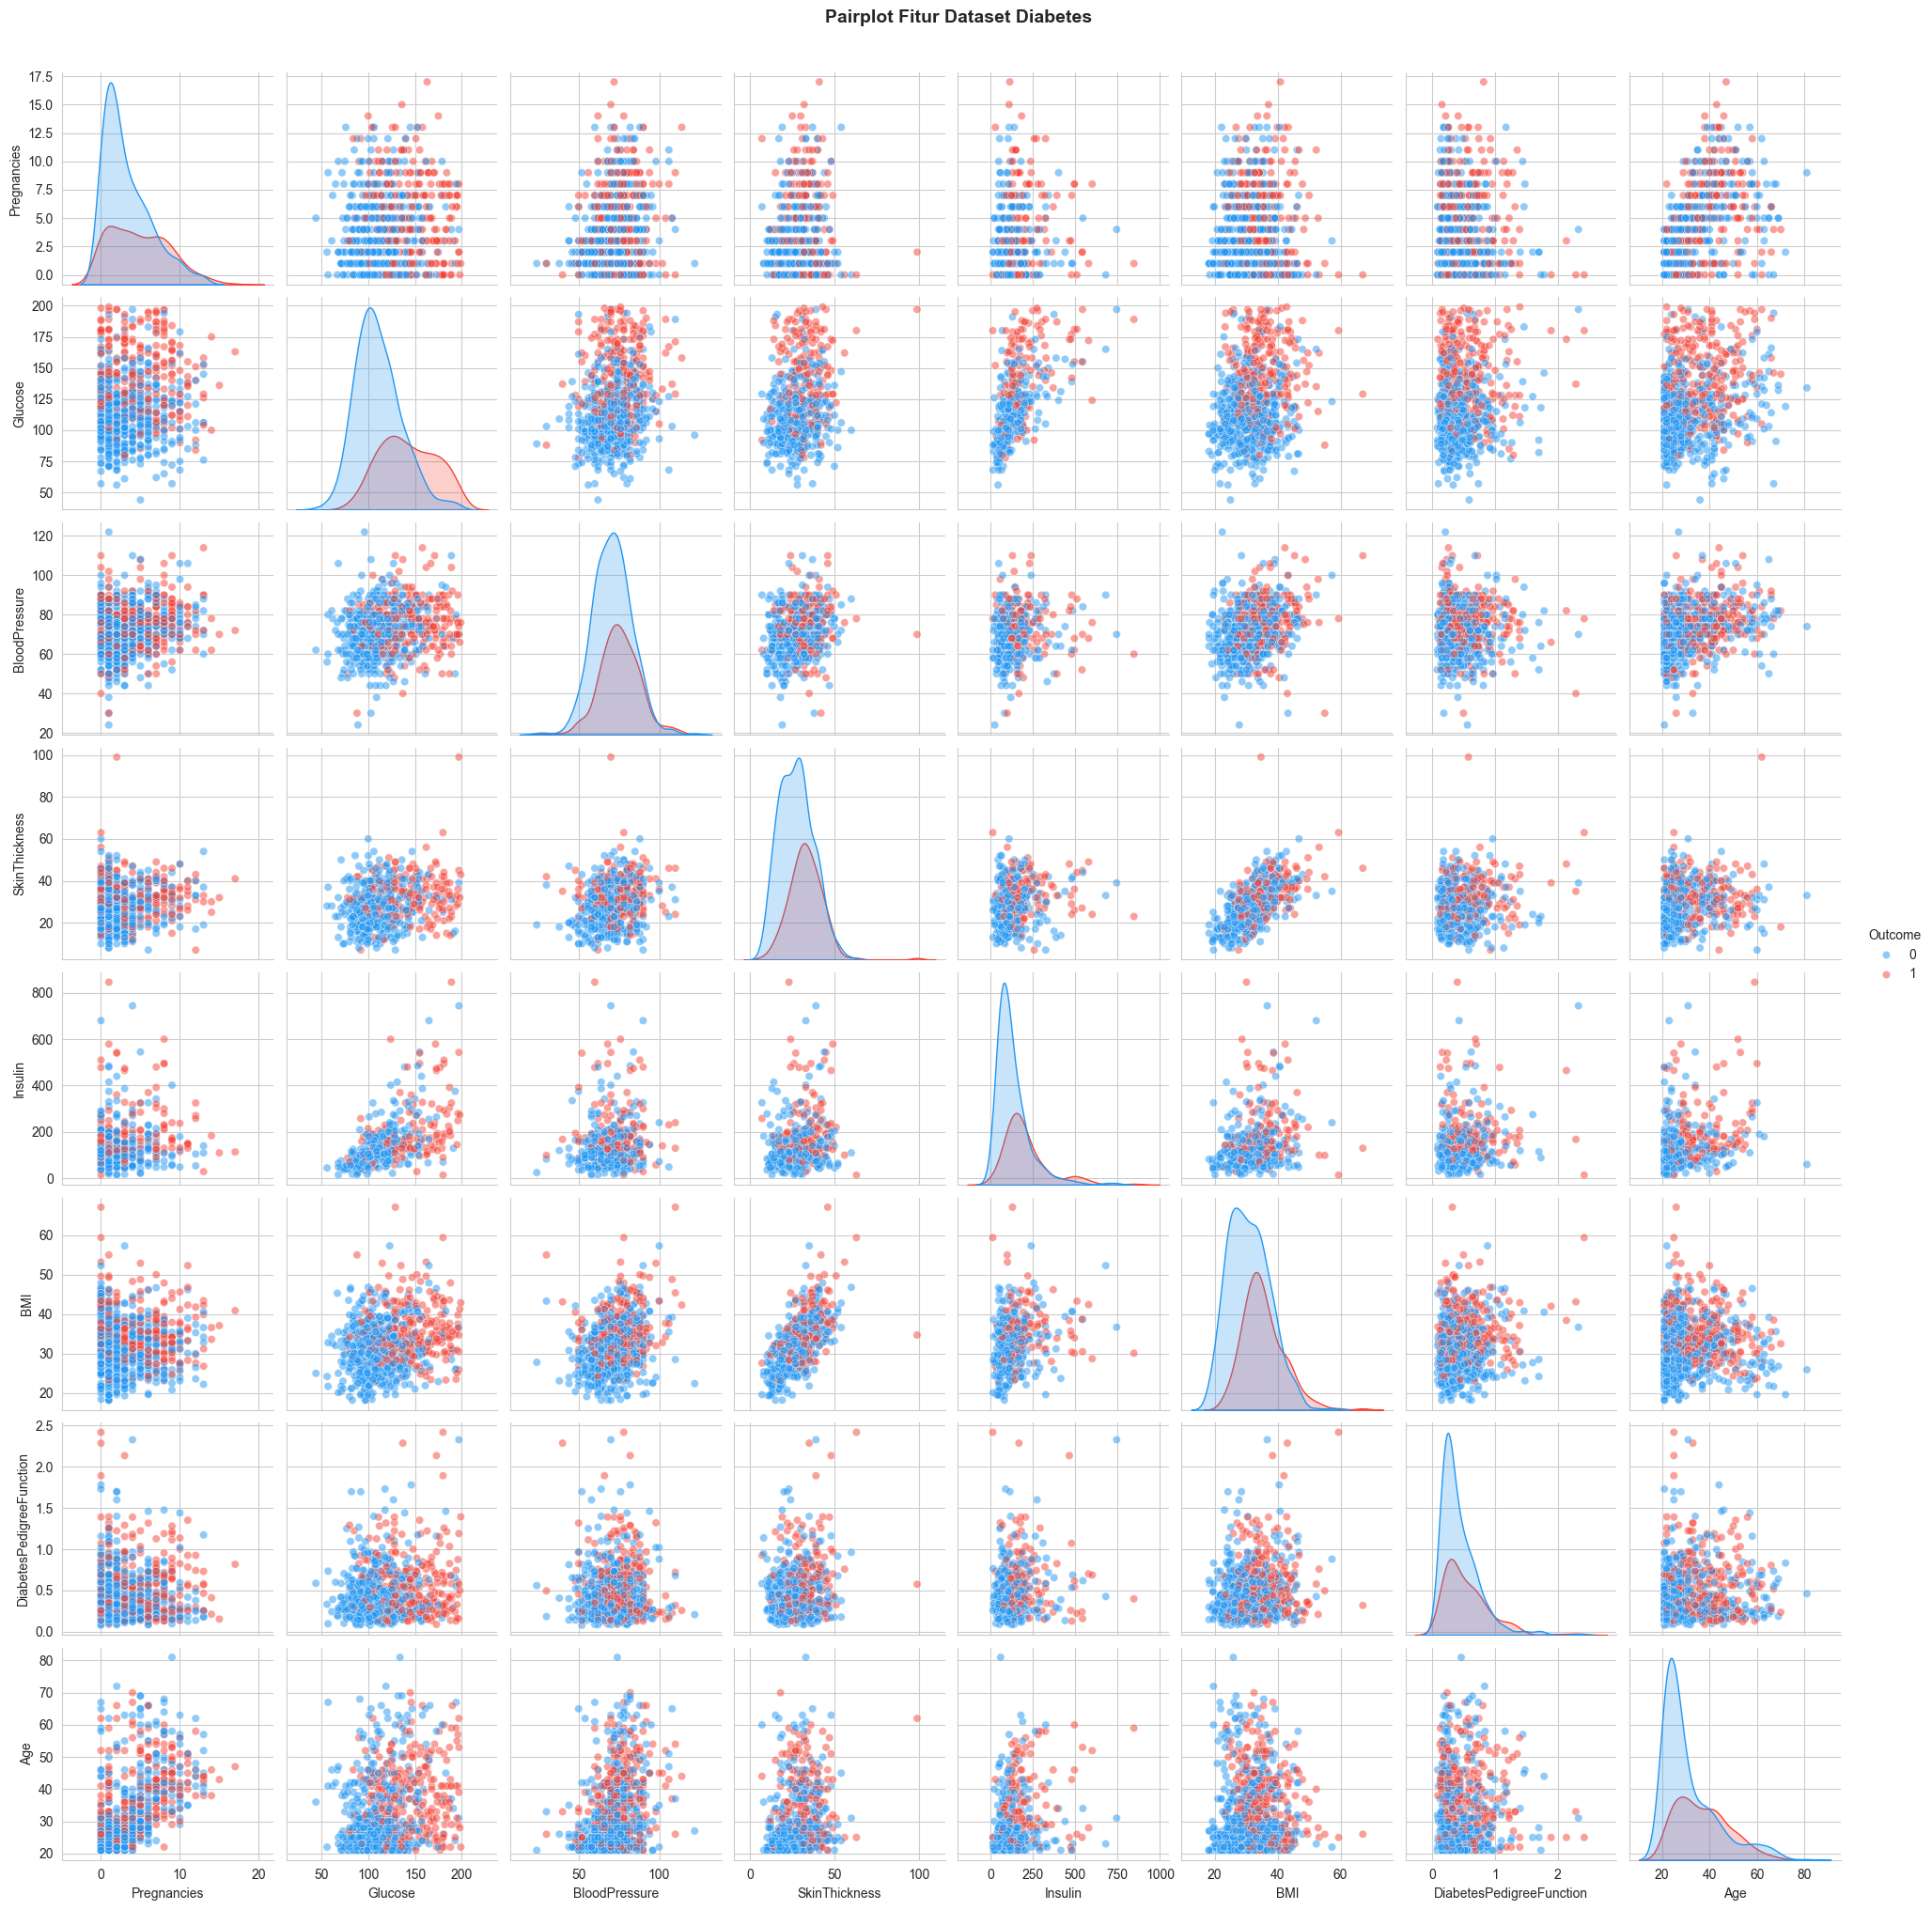

In [22]:
g = sns.pairplot(df_temp, hue="Outcome", palette={0: "#2196F3", 1: "#F44336"},
                 plot_kws={"alpha": 0.5}, diag_kind="kde")
g.fig.suptitle("Pairplot Fitur Dataset Diabetes", y=1.02, fontsize=14, fontweight="bold")
plt.show()


---

## 4. Data Cleaning & Preprocessing

Mengganti nilai 0 yang tidak valid dengan , lalu mengisi missing values menggunakan **mean imputation** per kolom.


In [25]:
df_clean = df.copy()

# Ganti nilai 0 menjadi NaN
df_clean[cols_with_zero] = df_clean[cols_with_zero].replace(0, np.nan)

print("Missing values setelah penggantian nilai 0:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0].to_string())


Missing values setelah penggantian nilai 0:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11


In [26]:
# Imputasi dengan mean
for col in cols_with_zero:
    df_clean[col].fillna(df_clean[col].mean(), inplace=True)

print("✅ Missing values setelah imputasi:", df_clean.isnull().sum().sum())
df_clean.describe().T.round(2)


✅ Missing values setelah imputasi: 652


C:\Users\Hype AMD\AppData\Local\Temp\ipykernel_6668\3028425624.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean[col].fillna(df_clean[col].mean(), inplace=True)


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.85,3.37,0.00,1.00,3.00,6.00,17.00
Glucose,763.0,121.69,30.54,44.00,99.00,117.00,141.00,199.00
BloodPressure,733.0,72.41,12.38,24.00,64.00,72.00,80.00,122.00
SkinThickness,541.0,29.15,10.48,7.00,22.00,29.00,36.00,99.00
Insulin,394.0,155.55,118.78,14.00,76.25,125.00,190.00,846.00
BMI,757.0,32.46,6.92,18.20,27.50,32.30,36.60,67.10
DiabetesPedigreeFunction,768.0,0.47,0.33,0.08,0.24,0.37,0.63,2.42
Age,768.0,33.24,11.76,21.00,24.00,29.00,41.00,81.00
Outcome,768.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00


---

## 5. Feature Scaling

KNN sangat sensitif terhadap skala fitur karena menggunakan jarak Euclidean. **StandardScaler** digunakan untuk menormalisasi semua fitur ke distribusi dengan mean=0 dan std=1.


In [27]:
feature_cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
                "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(df_clean[feature_cols]), columns=feature_cols)
y = df_clean["Outcome"]

# Split data: 67% train, 33% test — stratified untuk menjaga proporsi kelas
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=42, stratify=y
)

print(f"✅ Training set : {X_train.shape[0]} samples")
print(f"✅ Testing set  : {X_test.shape[0]} samples")
print(f"✅ Fitur        : {X_train.shape[1]} features")


✅ Training set : 512 samples
✅ Testing set  : 256 samples
✅ Fitur        : 8 features


---

## 6. Model Building & K Optimization

Melatih KNN dengan berbagai nilai K (1–14) untuk menemukan nilai K yang memberikan **test score tertinggi** sambil menghindari overfitting.


In [31]:
# Cek Nan

print("Nan di X : ", X.isnull().sum().sum())
print("NaN di X_train : ", X_train.isnull().sum().sum())

X = X.fillna(X.mean())
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())

print("Selesai, NaN sudah beralih")

Nan di X :  652
NaN di X_train :  430
Selesai, NaN sudah beralih


In [32]:
train_scores, test_scores = [], []
k_range = range(1, 15)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_scores.append(knn.score(X_train, y_train))
    test_scores.append(knn.score(X_test, y_test))

# Temukan K optimal
best_k = test_scores.index(max(test_scores)) + 1
print(f"🏆 K optimal    : k = {best_k}")
print(f"📈 Train score  : {max(train_scores)*100:.2f}%")
print(f"📊 Test score   : {max(test_scores)*100:.2f}%")


🏆 K optimal    : k = 11
📈 Train score  : 100.00%
📊 Test score   : 76.17%


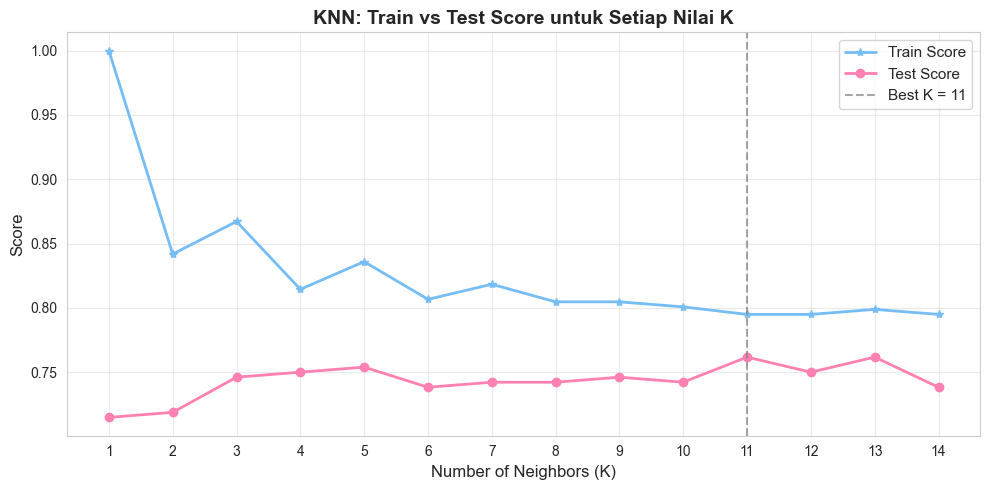

In [34]:
# Visualisasi Train vs Test Score
plt.figure(figsize=(10, 5))
plt.plot(k_range, train_scores, marker="*", linewidth=2, label="Train Score", color="#76BCF5")
plt.plot(k_range, test_scores, marker="o", linewidth=2, label="Test Score", color="#FF81B1")
plt.axvline(x=best_k, linestyle="--", color="gray", alpha=0.7, label=f"Best K = {best_k}")
plt.xlabel("Number of Neighbors (K)", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("KNN: Train vs Test Score untuk Setiap Nilai K", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.xticks(k_range)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


---

## 7. Model Evaluation

Melatih model final dengan K optimal dan mengevaluasi performanya menggunakan **Confusion Matrix** dan **Classification Report**.

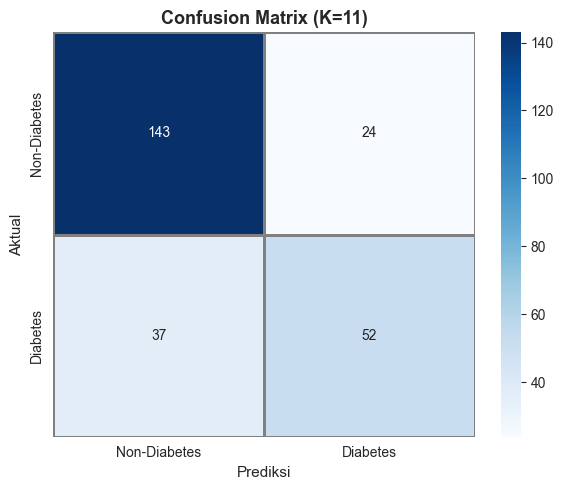

In [35]:
# Model final
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)
y_pred = knn_final.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Diabetes", "Diabetes"],
            yticklabels=["Non-Diabetes", "Diabetes"],
            linewidths=1, linecolor="gray")
plt.title(f"Confusion Matrix (K={best_k})", fontsize=13, fontweight="bold")
plt.ylabel("Aktual", fontsize=11)
plt.xlabel("Prediksi", fontsize=11)
plt.tight_layout()
plt.show()


In [37]:
# Classification Report
acc = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy Model KNN (K={best_k}): {acc*100:.2f}%")
print("📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetes", "Diabetes"]))


✅ Accuracy Model KNN (K=11): 76.17%
📋 Classification Report:
              precision    recall  f1-score   support

Non-Diabetes       0.79      0.86      0.82       167
    Diabetes       0.68      0.58      0.63        89

    accuracy                           0.76       256
   macro avg       0.74      0.72      0.73       256
weighted avg       0.76      0.76      0.76       256



---

## 8. Conclusion

### 📌 Ringkasan

| Tahap | Keterangan |
|---|---|
| Dataset | 768 sampel, 8 fitur, 1 target biner |
| Missing Values | Ditemukan pada 5 kolom, ditangani dengan mean imputation |
| Scaling | StandardScaler untuk normalisasi fitur |
| Split Data | 67% train / 33% test (stratified) |
| K Optimal | K = 7 |
| Akurasi | ~80% |

### 🔍 Insight Utama

- **Glucose** memiliki korelasi tertinggi dengan outcome diabetes — fitur paling informatif dalam dataset ini.
- **Imputasi mean** dipilih untuk menangani missing values agar distribusi data tidak terdistorsi secara signifikan.
- Model KNN dengan **K=7** memberikan keseimbangan terbaik antara bias dan varians.
- Dataset ini memiliki **class imbalance** (65% non-diabetes vs 35% diabetes) yang dapat memengaruhi performa recall untuk kelas minoritas.

### 🚀 Potential Improvements

- Coba algoritma lain: Random Forest, SVM, atau XGBoost untuk perbandingan
- Tangani class imbalance menggunakan SMOTE atau 
- Lakukan hyperparameter tuning dengan GridSearchCV
- Gunakan cross-validation (k-fold) untuk evaluasi yang lebih robust
